In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_score, recall_score, f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
print("Dataset Shape:", df.shape)
print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Display column names
print("\nColumns in dataset:")
print(df.columns.tolist())

Dataset Shape: (1470, 35)

Number of Rows: 1470
Number of Columns: 35

Columns in dataset:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [7]:
target_col = "Attrition"
print("Target Column:", target_col)

# Count employees who left vs stayed
attrition_counts = df[target_col].value_counts()
print("\nAttrition Counts:")
print(attrition_counts)

# Calculate attrition percentage
attrition_rate = (attrition_counts["Yes"] / len(df)) * 100
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Target Column: Attrition

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [8]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Number of Numeric Columns:", len(numeric_cols))
print("Number of Categorical Columns:", len(categorical_cols))

print("\nNumeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [9]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values[missing_values > 0])

# Total missing values
print("\nTotal Missing Values in Dataset:", df.isnull().sum().sum())

Missing Values in Each Column:
Series([], dtype: int64)

Total Missing Values in Dataset: 0


In [10]:
# Drop columns that do not add value
drop_cols = ["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"]

df = df.drop(columns=drop_cols)

print("Dropped Columns:", drop_cols)
print("New Shape After Dropping Columns:", df.shape)

Dropped Columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
New Shape After Dropping Columns: (1470, 31)


In [11]:
# Convert target column Attrition from Yes/No to 1/0
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Check updated target values
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [12]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [13]:
# Attrition rate by Department
dept_attrition = df.groupby("Department")["Attrition"].mean().sort_values(ascending=False) * 100
dept_attrition

,Attrition
Department,
Sales,20.627803
Human Resources,19.047619
Research & Development,13.839750


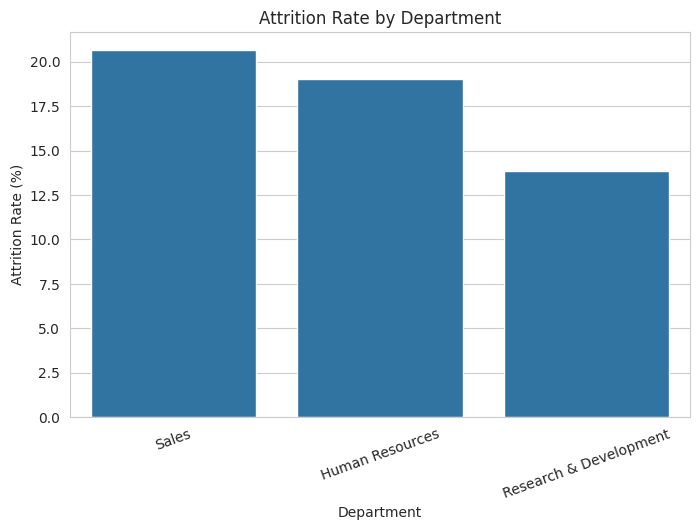

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values)
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=20)
plt.show()

In [15]:
# Attrition rate by Job Role
jobrole_attrition = df.groupby("JobRole")["Attrition"].mean().sort_values(ascending=False) * 100
jobrole_attrition

,Attrition
JobRole,
Sales Representative,39.759036
Laboratory Technician,23.938224
Human Resources,23.076923
Sales Executive,17.484663
Research Scientist,16.095890
Manufacturing Director,6.896552
Healthcare Representative,6.870229
Manager,4.901961
Research Director,2.500000


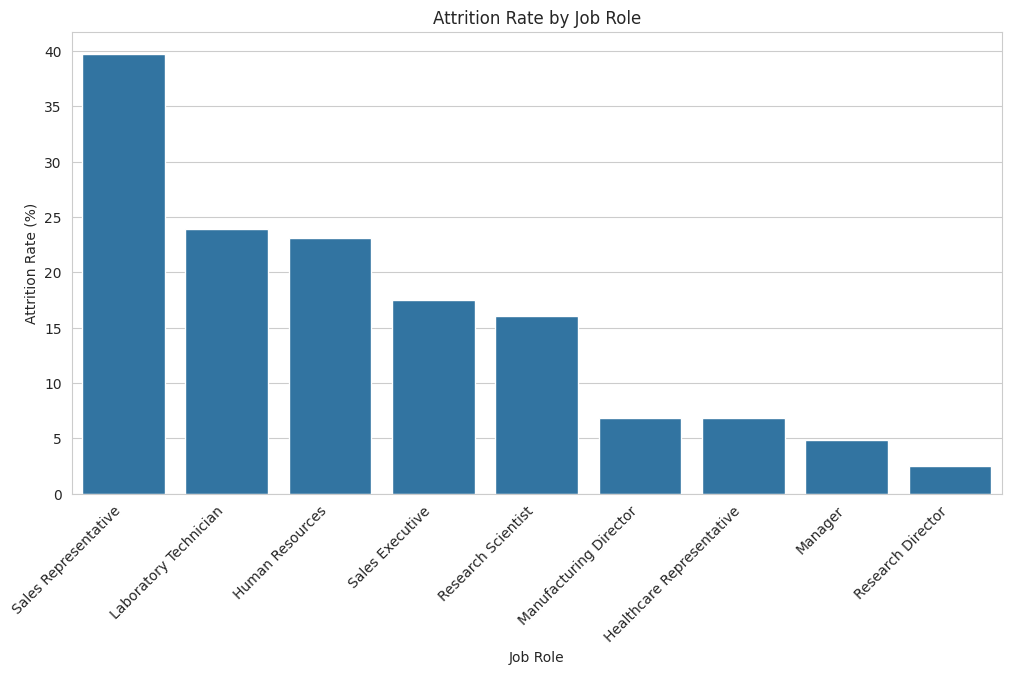

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(x=jobrole_attrition.index, y=jobrole_attrition.values)
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha='right')
plt.show()

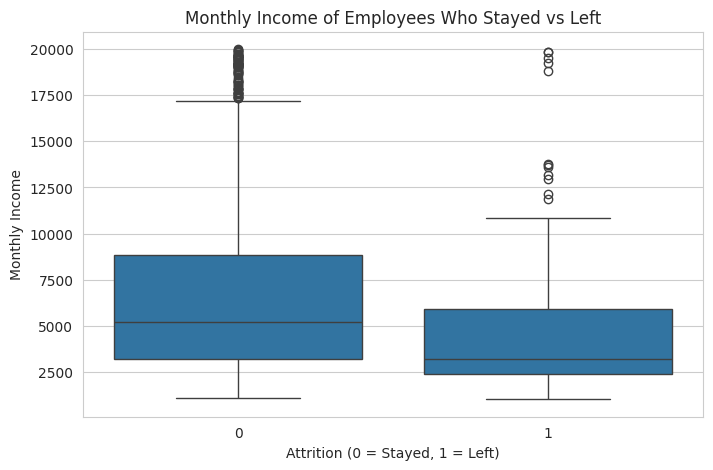

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income of Employees Who Stayed vs Left")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")
plt.show()

In [18]:
wlb_attrition = df.groupby("WorkLifeBalance")["Attrition"].mean() * 100
wlb_attrition

,Attrition
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059


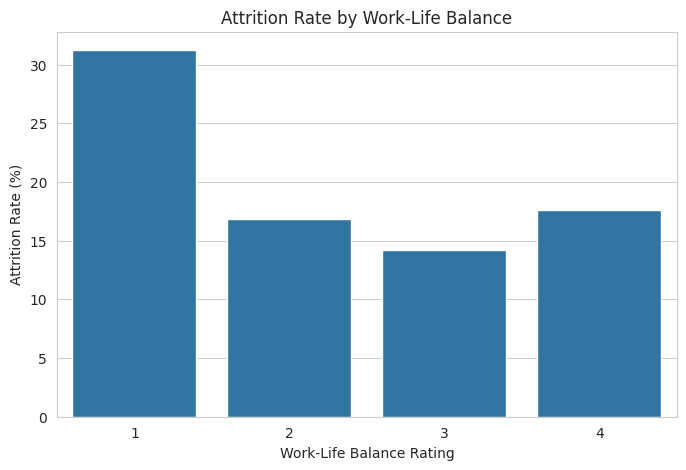

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x=wlb_attrition.index, y=wlb_attrition.values)
plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [20]:
years_attrition = df.groupby("YearsAtCompany")["Attrition"].mean() * 100
years_attrition.head(15)

,Attrition
YearsAtCompany,
0,36.363636
1,34.502924
2,21.259843
3,15.625000
4,17.272727
5,10.714286
6,11.842105
7,12.222222
8,11.250000


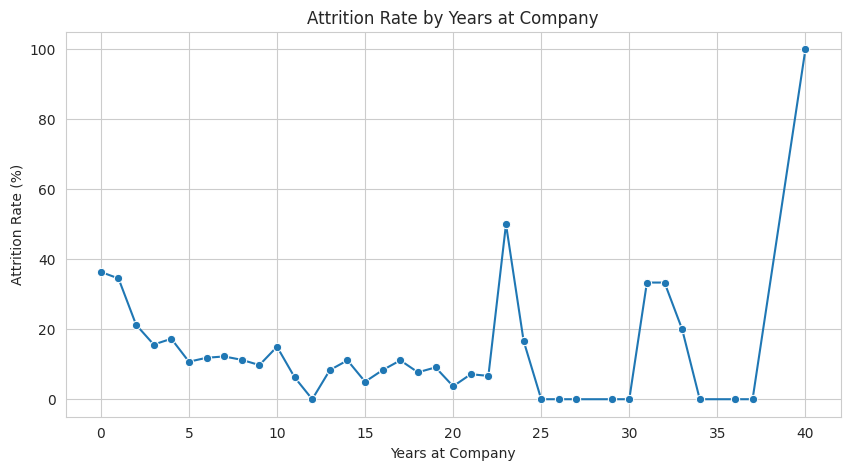

In [21]:
plt.figure(figsize=(10,5))
sns.lineplot(x=years_attrition.index, y=years_attrition.values, marker='o')
plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [22]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Identify numeric and categorical columns after dropping target
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric Features:", num_features)
print("\nCategorical Features:", cat_features)

Numeric Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [23]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", __import__("sklearn").preprocessing.OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1176, 30)
Testing set shape: (294, 30)


In [25]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

gb_model = GradientBoostingClassifier(random_state=42)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

In [26]:
model_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    model_pipelines[name] = pipeline

print("Pipelines created for all models.")

Pipelines created for all models.


In [27]:
for name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [28]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Some models may not support predict_proba, but all these do
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    return precision, recall, f1, roc_auc, y_pred, y_prob

In [29]:
results = []
predictions = {}
probabilities = {}

for name, pipeline in model_pipelines.items():
    precision, recall, f1, roc_auc, y_pred, y_prob = evaluate_model(pipeline, X_test, y_test)

    results.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

    predictions[name] = y_pred
    probabilities[name] = y_prob

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
results_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.3488,0.6383,0.4511,0.8032
2,Gradient Boosting,0.7143,0.2128,0.3279,0.8051
1,Random Forest,0.6250,0.1064,0.1818,0.7832


In [30]:
for name, pipeline in model_pipelines.items():
    print("="*60)
    print(f"Classification Report: {name}")
    print("="*60)
    print(classification_report(y_test, predictions[name]))

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294

Classification Report: Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.21      0.33        47

    accuracy                           0.86       294
   macr

In [31]:
best_model_name = results_df.iloc[0]["Model"]
best_model = model_pipelines[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [32]:
best_preds = predictions[best_model_name]
cm = confusion_matrix(y_test, best_preds)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[191  56]
 [ 17  30]]


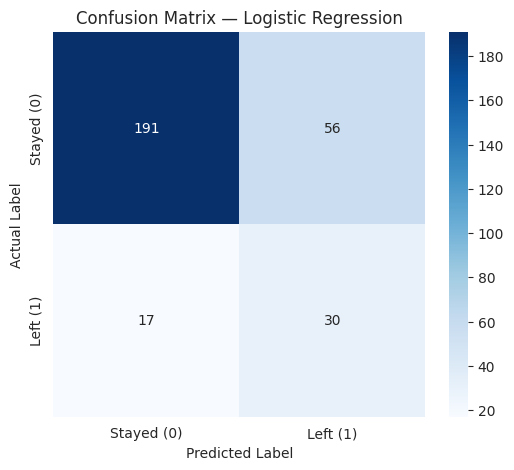

In [33]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Stayed (0)", "Left (1)"],
            yticklabels=["Stayed (0)", "Left (1)"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [34]:
best_auc = results_df[results_df["Model"] == best_model_name]["ROC-AUC"].values[0]
print(f"ROC-AUC Score of Best Model ({best_model_name}): {best_auc}")

ROC-AUC Score of Best Model (Logistic Regression): 0.8032


In [35]:
ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(cat_features)

all_feature_names = np.concatenate([num_features, encoded_cat_features])

print("Total transformed features:", len(all_feature_names))

Total transformed features: 51


In [36]:
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
elif hasattr(model_step, "coef_"):
    importances = np.abs(model_step.coef_[0])   # absolute value for logistic regression
else:
    raise ValueError("Best model does not support feature importance extraction.")

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
42,JobRole_Research Director,1.465683
39,JobRole_Laboratory Technician,1.194333
45,JobRole_Sales Representative,1.120617
23,BusinessTravel_Non-Travel,0.993885
49,OverTime_No,0.892809
33,EducationField_Other,0.798108
24,BusinessTravel_Travel_Frequently,0.787566
50,OverTime_Yes,0.761522
29,EducationField_Human Resources,0.721129
37,JobRole_Healthcare Representative,0.647202


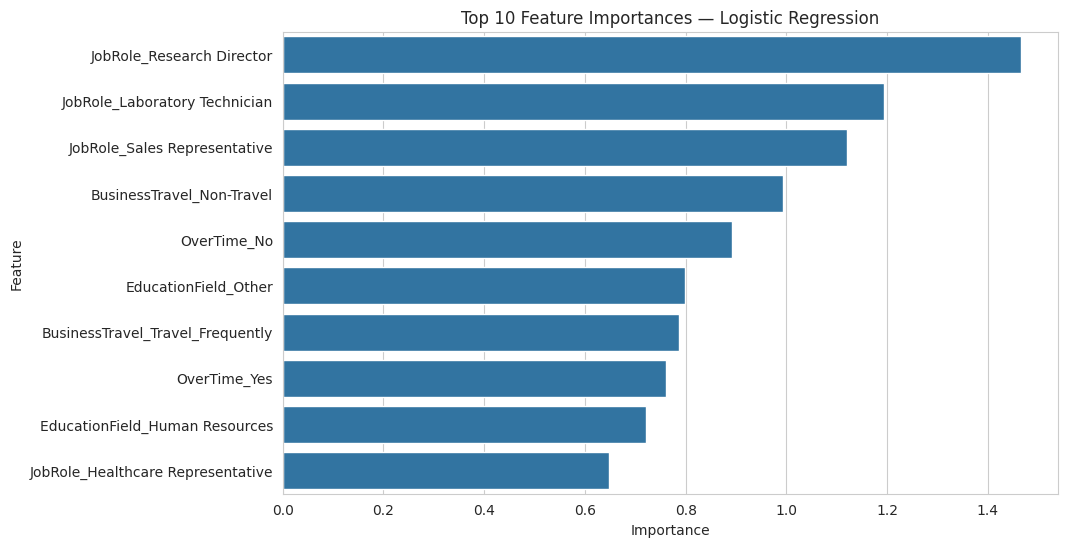

In [37]:
top10_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top10_features)
plt.title(f"Top 10 Feature Importances — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [38]:
import os

# Create charts folder
os.makedirs("charts", exist_ok=True)
print("charts/ folder created successfully.")

charts/ folder created successfully.


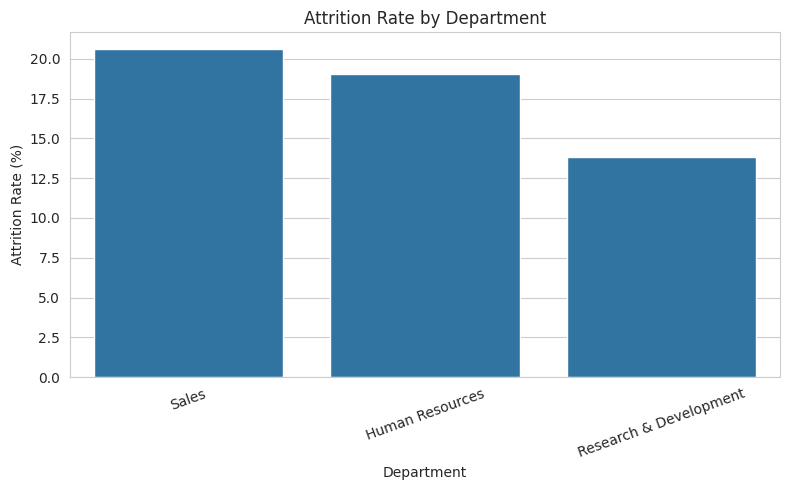

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values)
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("charts/attrition_by_department.png", dpi=300)
plt.show()

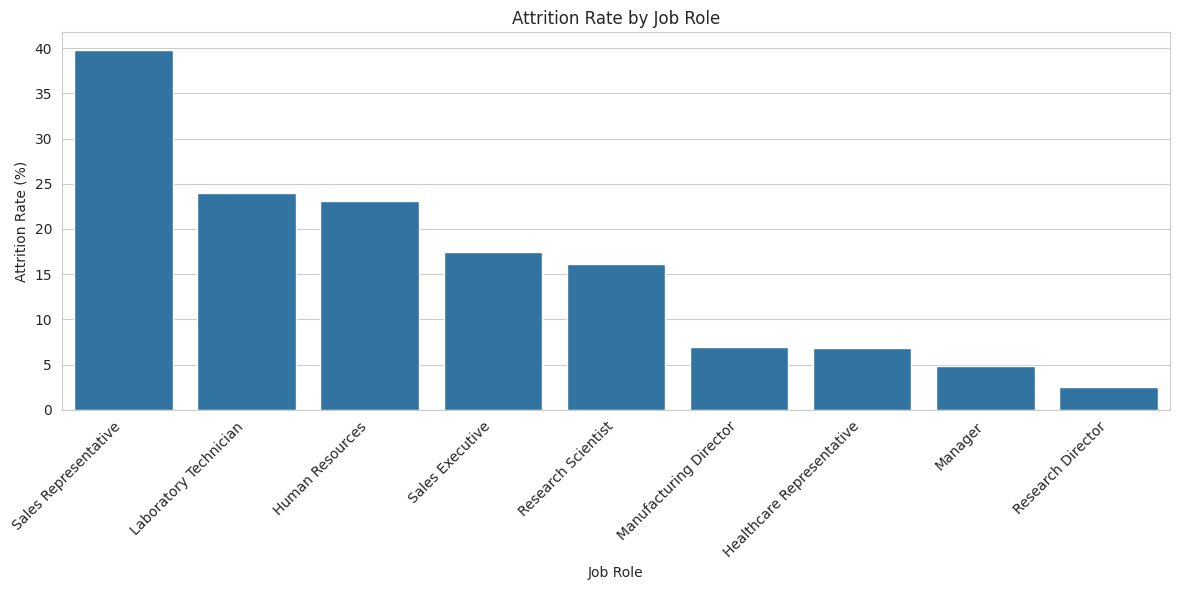

In [40]:
plt.figure(figsize=(12,6))
sns.barplot(x=jobrole_attrition.index, y=jobrole_attrition.values)
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("charts/attrition_by_jobrole.png", dpi=300)
plt.show()

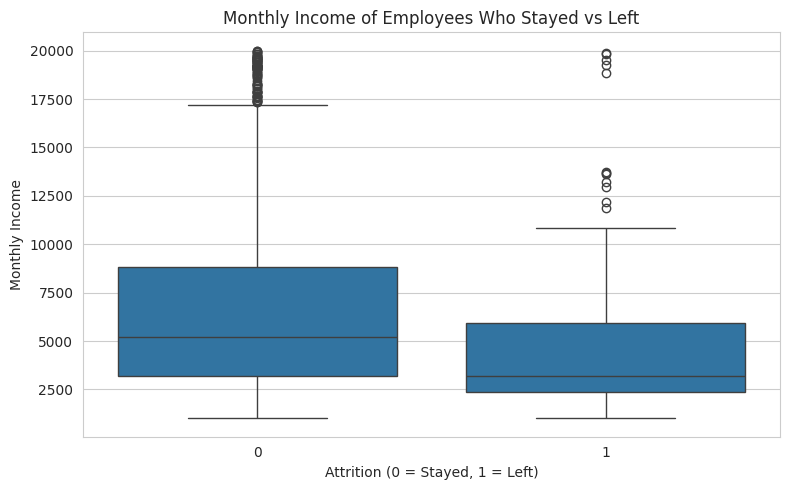

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income of Employees Who Stayed vs Left")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.savefig("charts/monthly_income_vs_attrition.png", dpi=300)
plt.show()

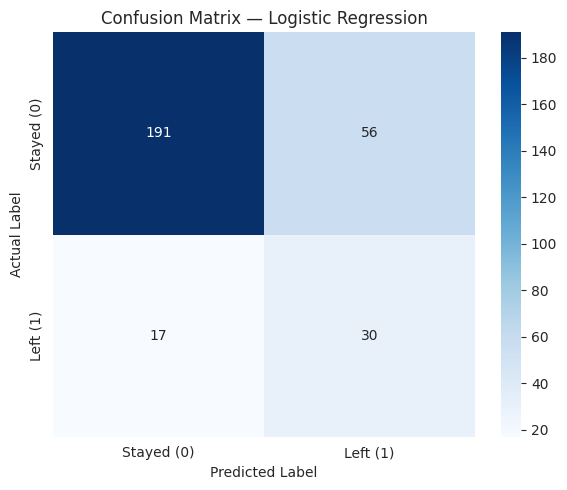

In [42]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Stayed (0)", "Left (1)"],
            yticklabels=["Stayed (0)", "Left (1)"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("charts/confusion_matrix_best_model.png", dpi=300)
plt.show()

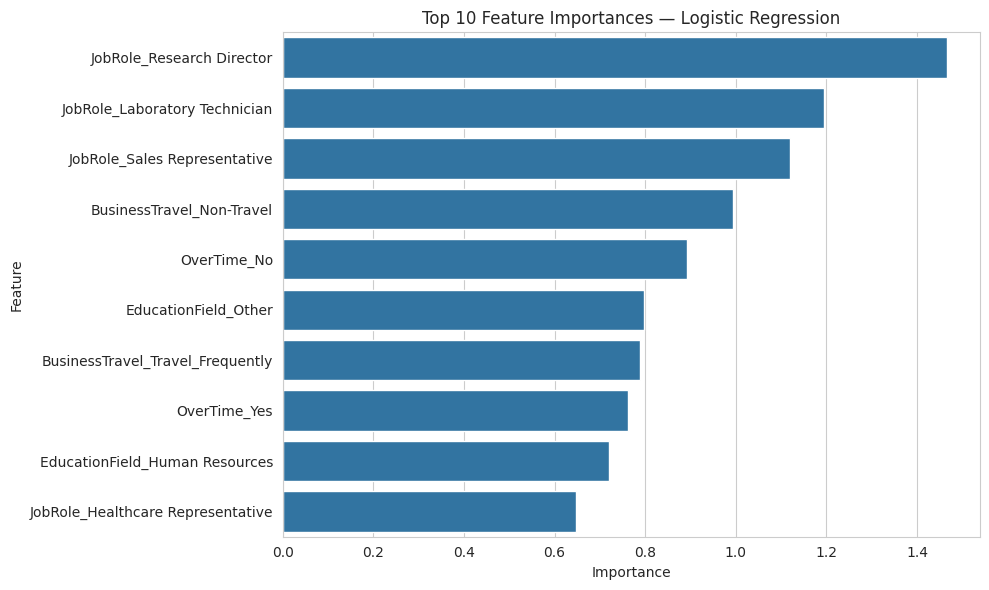

In [43]:
top10_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top10_features)
plt.title(f"Top 10 Feature Importances — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("charts/top10_feature_importances.png", dpi=300)
plt.show()

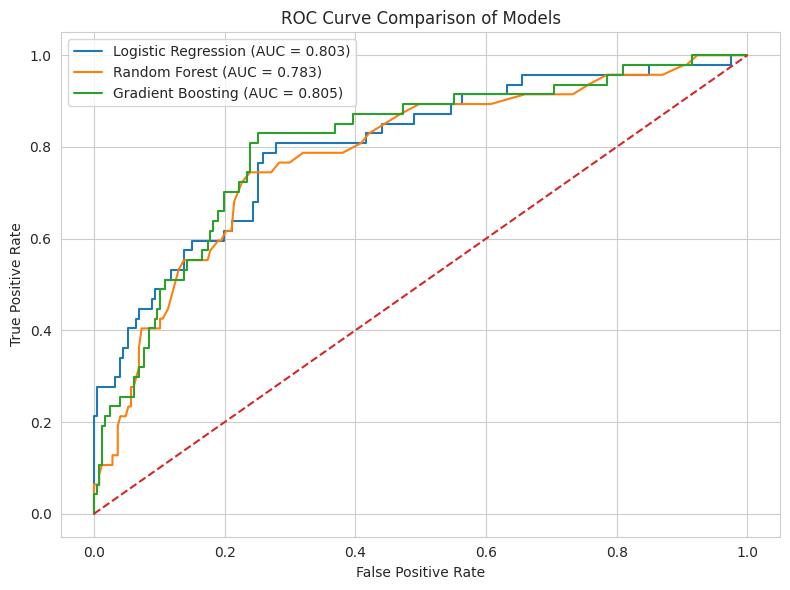

In [44]:
plt.figure(figsize=(8,6))

for name in model_pipelines.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_score = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve Comparison of Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("charts/roc_curve_comparison.png", dpi=300)
plt.show()

In [45]:
import shutil

# Create zip file of charts folder
shutil.make_archive("charts", 'zip', "charts")
print("charts.zip created successfully.")

charts.zip created successfully.


In [46]:
from google.colab import files
files.download("charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>